# Phishing website prediction (Business understanding)
The goal of this algorithm is to predict whether a given website is a phishing site or legitimate.
Decision trees and random forests are used to interpret the dataset and build the model.
If this algorithm is successful, it could be used to automatically warn users of dangerous websites.

In [134]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
phishing_websites = fetch_ucirepo(id=327) 

# extract pd dataframe from dataset and describe it
df = pd.DataFrame(phishing_websites.data.original)
df.describe(include='all')

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Data understanding
The variables are not very self-explanatory, but for this model we assume that -1 = phishing and 1 = legitimate.
Various properties of websites within the dataset are analyzed to see what characteristics separate 1 and -1.

First, a decision tree is built in order to get an idea of which properties are most significant.

In [135]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree  

X = df.drop(['result'], axis = 1) # input
y = df['result'] # target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8844, 30) (2211, 30) (8844,) (2211,)


In [136]:
model = DecisionTreeClassifier(max_depth=3, random_state=20)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Now that the model has been created, matplotlib can visualize it.
This should help make sense of this dataset.

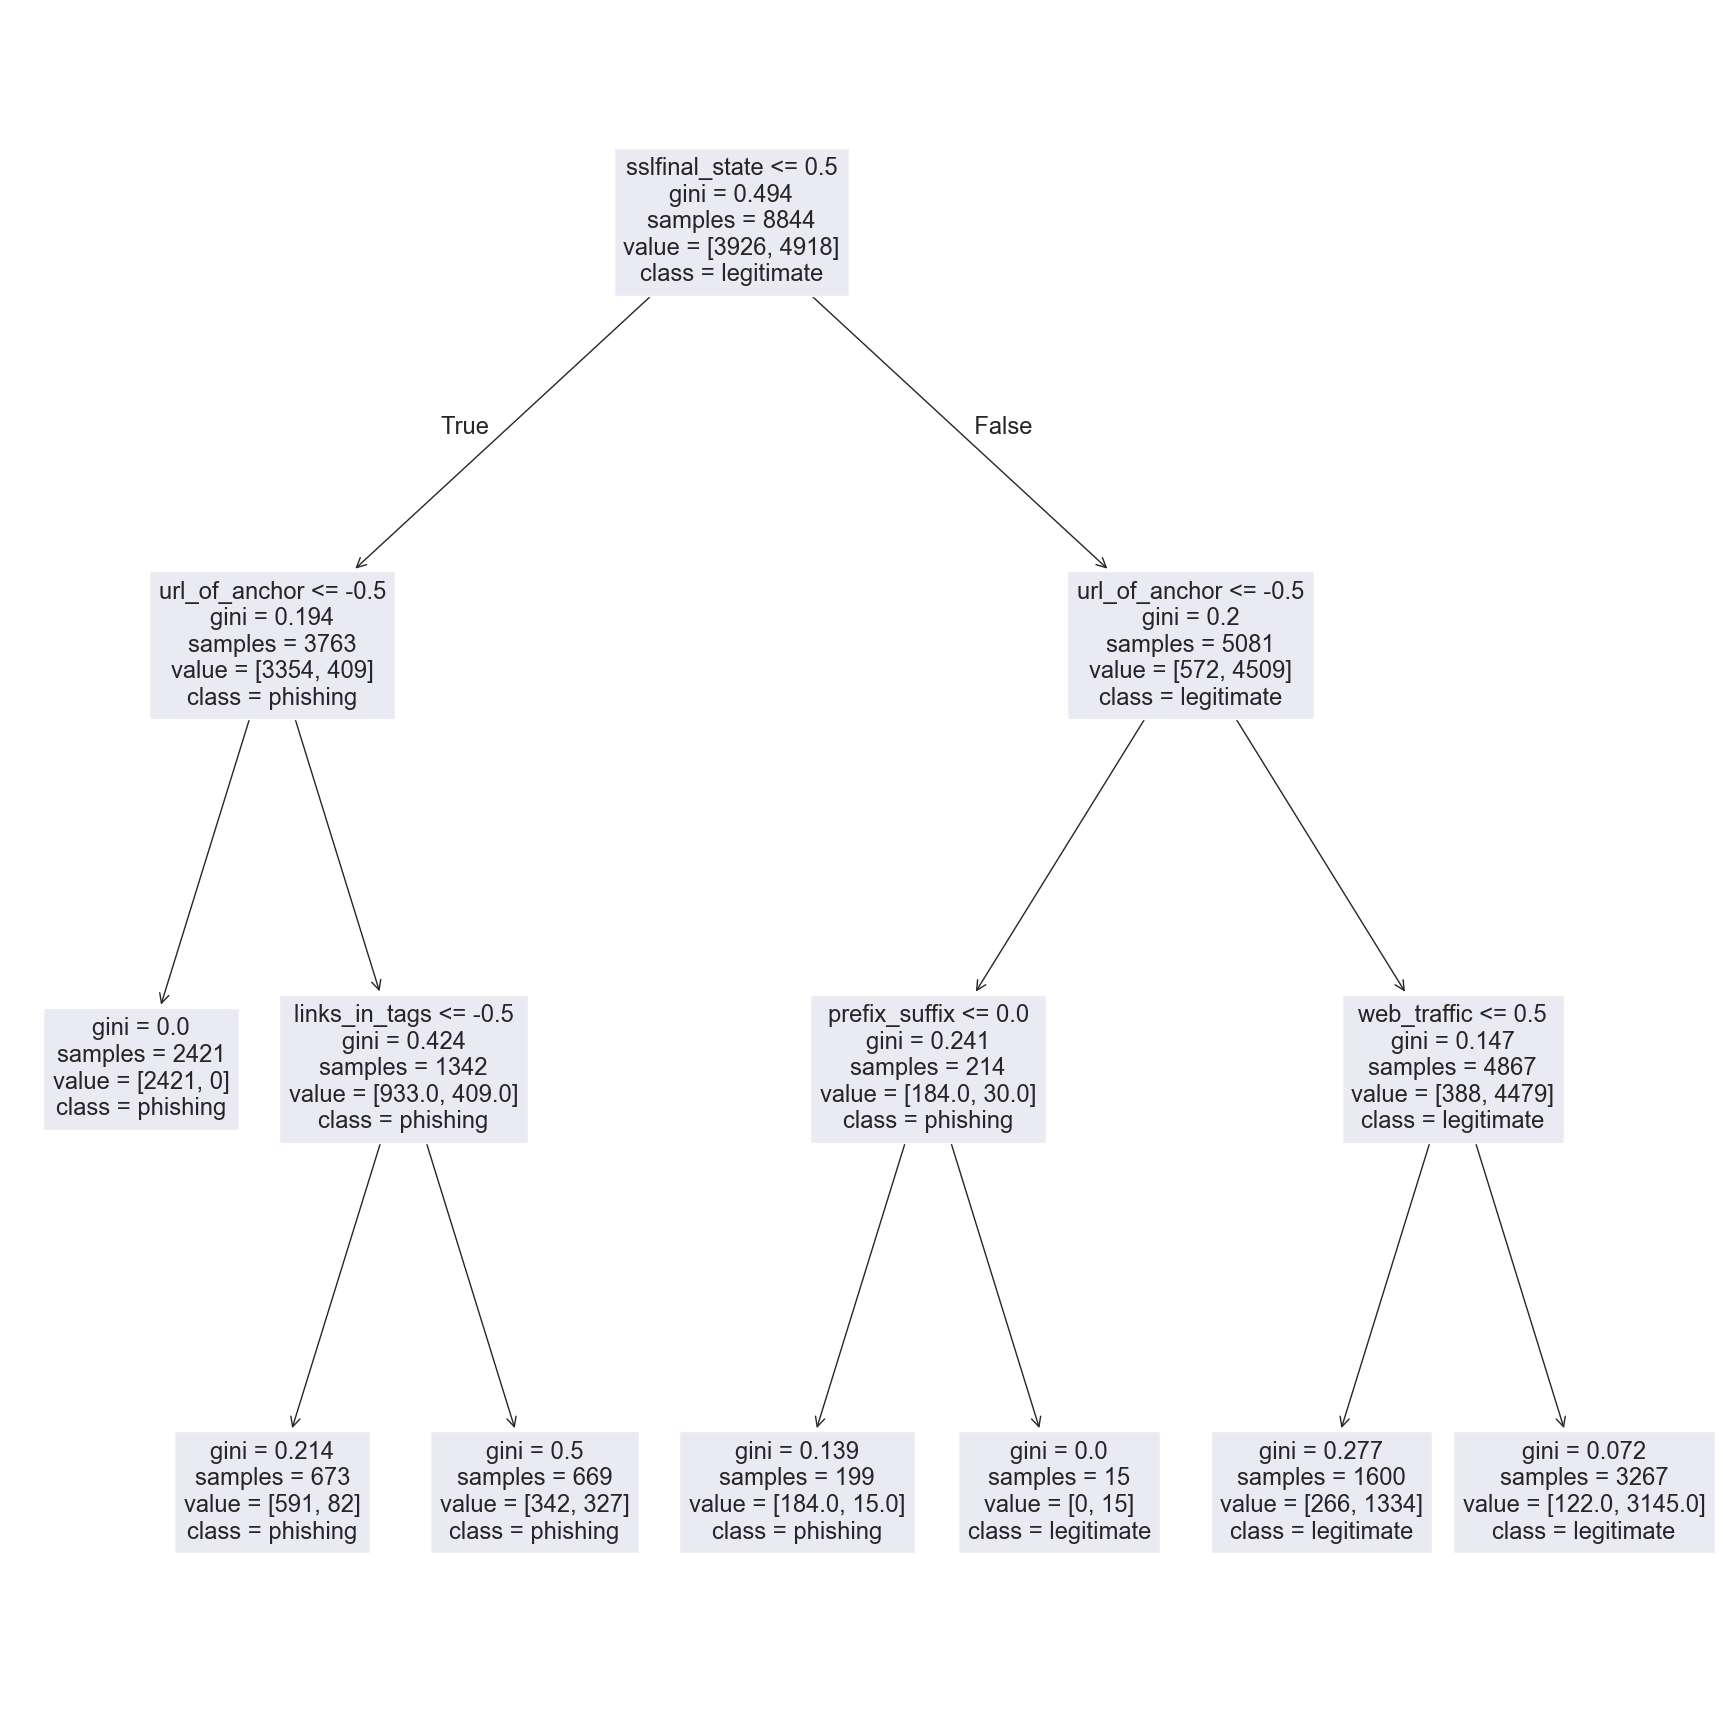

In [137]:
fig = plt.figure(figsize = (22, 22))
plot_tree(model, feature_names = X.keys(), class_names = ['phishing', 'legitimate'])
plt.show()

From this initial tree, it can be assumed that the single most significant property is sslfinal_state.
If a website does not provide a secure connection, it would be safe to assume it is not legitimate.
Next, the tree has decided that url_of_anchor is also an important indicator. According to documentation,
some features to look for are url shortening services (example: TinyURL) or using '@' in the url.

In [138]:
from sklearn.metrics import classification_report

tree_pred = model.predict(X_test)
# create classification report for current model
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

          -1       0.88      0.91      0.90       972
           1       0.93      0.90      0.92      1239

    accuracy                           0.91      2211
   macro avg       0.90      0.91      0.91      2211
weighted avg       0.91      0.91      0.91      2211


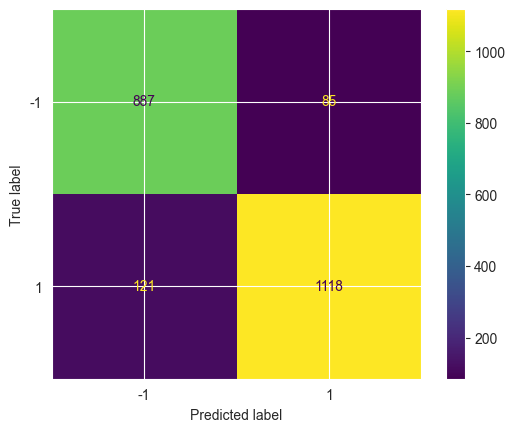

In [139]:
from sklearn.metrics import ConfusionMatrixDisplay

# display confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

## Instructions for manual checking
These instructions should allow any knowledgeable person to manually check whether a site is legitimate or not.
First, check if the website has an SSL certificate that provides a secure connection. If this step fails, it is highly likely that the website is not legitimate.  
Next, check if there is a "URL of Anchor", meaning that the website's <a> tags have different domain names. Another example is <a> tags that do not link to any webpage. If a website fails both of these initial checks, it is, according to the model, definitely a phishing site.

After the first two checks, the differences become smaller. The following steps should help the final classification; check if the website has high traffic as that is a sign of it being legitimate. Check if there are links that don't lead to the same domain in the website's tags, and if there are, classify as phishing. Check if there are dash (-) symbols in the url, as these are rarely used by legitimate websites, and if there are, classify as phishing.



# Modeling
Now, it is possible to build a proper automated model based on the data gathered. To do this, a random forest will be created with various properties tested. This step should finally show if the initial goal of this algorithm is viable.

In [140]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# create random forest
rand_forest = RandomForestClassifier(n_estimators=100, bootstrap=True, max_samples=0.7, max_features=0.75, random_state=123, oob_score=True)

# Method 1: cross validation
cv_scores = cross_val_score(rand_forest, X, y, cv=10)

# Method 2: OOB score
rand_forest.fit(X, y)
oob_score = rand_forest.oob_score_

# check if the forest is more or less accurate than the previously built tree.
print(f"Fold-specific accuracies: {cv_scores}")
print(f"Overall accuracy (cross validation): {cv_scores.mean():.4f}")
print(f"Overall accuracy (OOB): {oob_score:.4f}")

Fold-specific accuracies: [0.98553345 0.98282098 0.97287523 0.98372514 0.97830018 0.97375566
 0.96108597 0.94298643 0.96289593 0.95837104]
Overall accuracy (cross validation): 0.9702
Overall accuracy (OOB): 0.9730


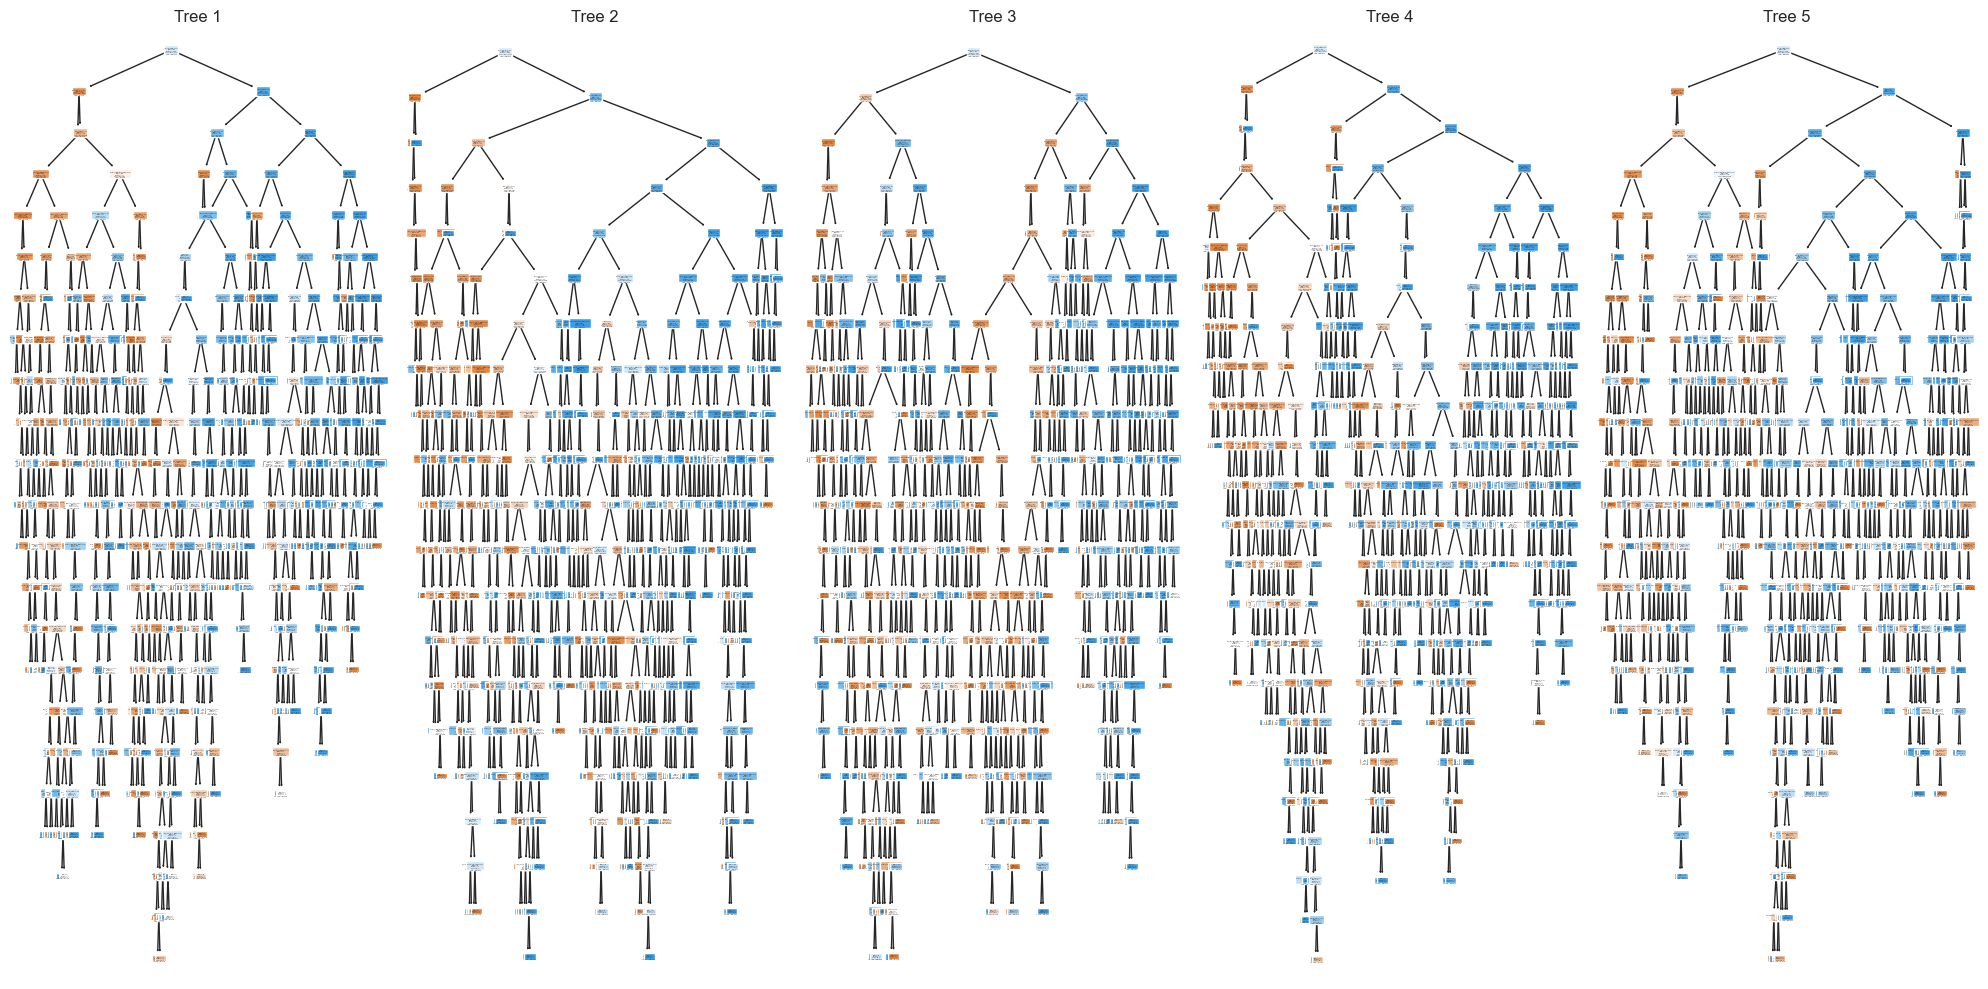

In [141]:
n_trees_to_plot = 5

plt.figure(figsize=(20, 10))


for i in range(n_trees_to_plot):
    plt.subplot(1, n_trees_to_plot, i + 1)  # 1 row and n_trees_to_plot columns
    plot_tree(rand_forest.estimators_[i], filled=True,
              feature_names=X.keys(), class_names=['phishing', 'legitimate'])
    plt.title(f'Tree {i + 1}')

plt.tight_layout()
plt.show()

The forest does not have a set max depth, so it ends up being quite unreadable. The forest does achieve a very respectable 97% accuracy, much better than the decision tree. Next, a confusion matrix should help visualize this mess and make it more readable.

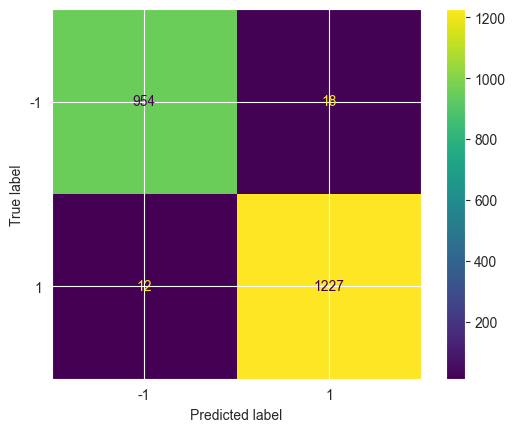

In [142]:
# display confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(rand_forest, X_test, y_test)

# Evaluation
Based on these findings, it seems that a random forest is more accurate than a decision tree when it comes to predicting legitimate and phishing websites in this dataset.
The decision tree achieved an accuracy of 91%, while the random forest reached 97%. 

This algorithm has the potential to accurately predict a website's legitimacy within these parameters. The initial goal is reached.